Dataset Loaded Successfully! Rows: 50000


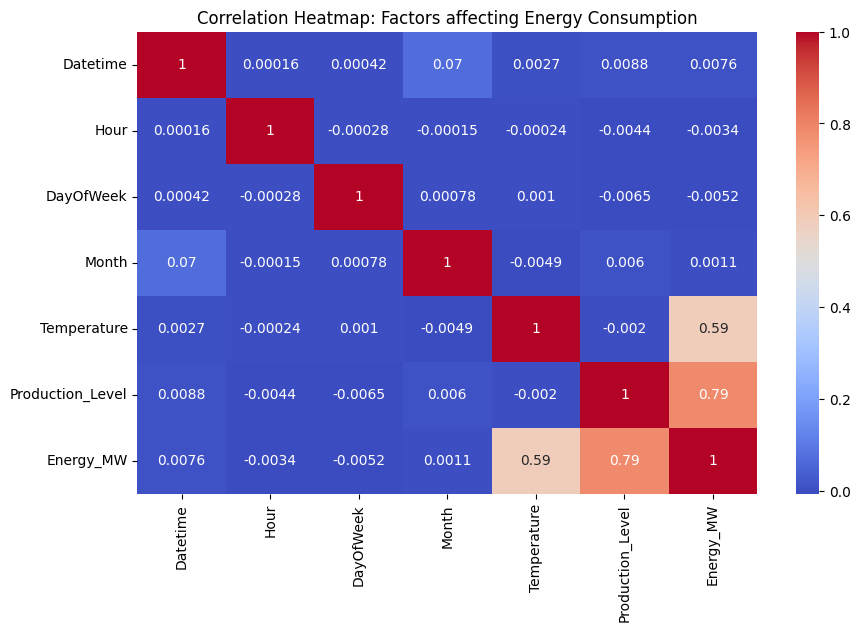

[0]	validation_0-rmse:250.98702
[100]	validation_0-rmse:50.15853
[156]	validation_0-rmse:50.21061

--- Model Performance ---
Mean Absolute Error (MAE): 39.98 MW
R-Squared Score (Accuracy): 96.38%
RMSE: 50.15 MW


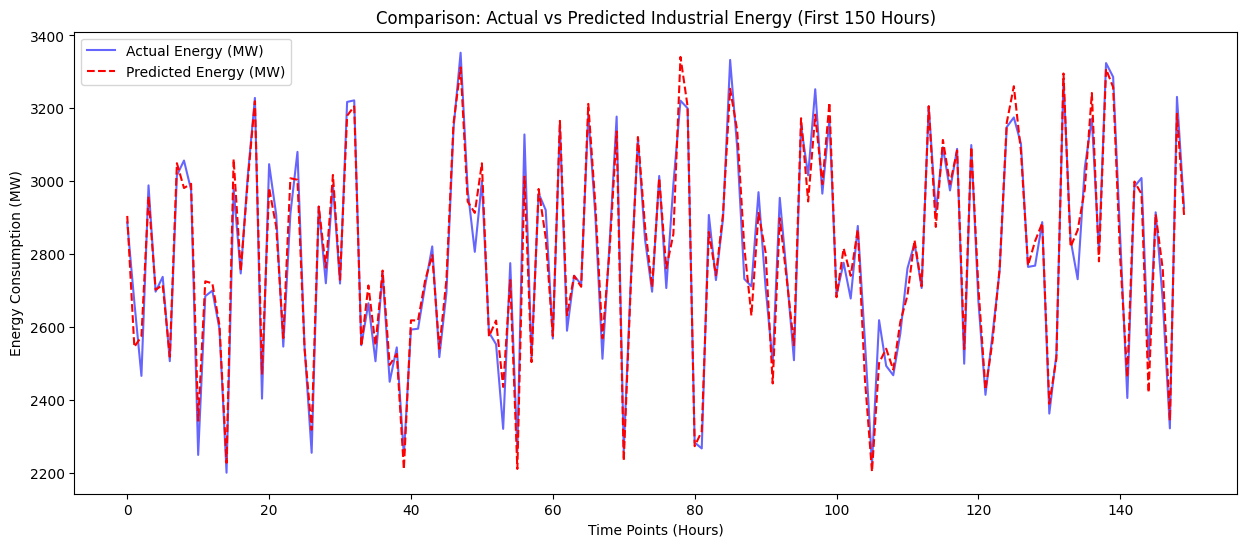

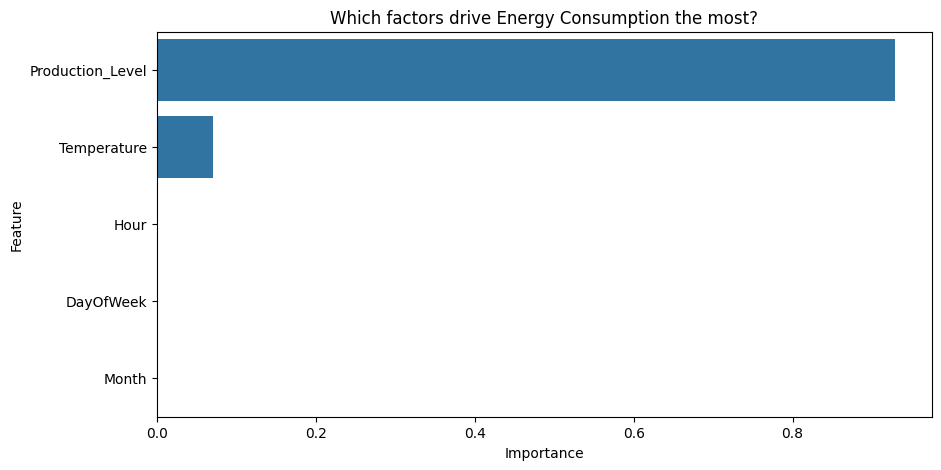


Demo Prediction: Estimated Energy for the given scenario is 3203.96 MW


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. LOAD DATASET
# Maan lijiye aapne file ka naam 'industrial_energy_advanced.csv' rakha hai
df = pd.read_csv(r"C:\Users\Mithlesh Maurya\Desktop\Project\industrial_energy_advanced.csv")

# Datetime ko proper format mein convert karna (taaki sorting sahi ho)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

print("Dataset Loaded Successfully! Rows:", len(df))

# 2. EXPLORATORY DATA ANALYSIS (EDA) - Reports ke liye Graphs
# Correlation Heatmap (Ye dikhayega ki Temperature aur Production ka Energy par kitna asar hai)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Factors affecting Energy Consumption')
plt.show()

# 3. FEATURE SELECTION
# Hum 'Datetime' ko drop kar rahe hain kyunki humne Hour, Month, etc. pehle hi nikal liye hain
X = df[['Hour', 'DayOfWeek', 'Month', 'Temperature', 'Production_Level']]
y = df['Energy_MW']

# 4. TRAIN-TEST SPLIT (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MODEL BUILDING (XGBoost Regressor)
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=5, 
    early_stopping_rounds=50
)

# Model Training
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# 6. PREDICTIONS & EVALUATION
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} MW")
print(f"R-Squared Score (Accuracy): {r2*100:.2f}%")
print(f"RMSE: {rmse:.2f} MW")

# 7. ACTUAL VS PREDICTED VISUALIZATION
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:150], label='Actual Energy (MW)', color='blue', alpha=0.6)
plt.plot(y_pred[:150], label='Predicted Energy (MW)', color='red', linestyle='--')
plt.title('Comparison: Actual vs Predicted Industrial Energy (First 150 Hours)')
plt.xlabel('Time Points (Hours)')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.show()

# 8. FEATURE IMPORTANCE (Kaunsa factor sabse zaruri hai?)
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Which factors drive Energy Consumption the most?')
plt.show()

# 9. REAL-TIME PREDICTION FUNCTION (For Demo)
def predict_energy(hour, day, month, temp, prod_level):
    input_data = pd.DataFrame([[hour, day, month, temp, prod_level]], 
                              columns=['Hour', 'DayOfWeek', 'Month', 'Temperature', 'Production_Level'])
    prediction = model.predict(input_data)
    return prediction[0]

# Demo: Monday (0), 2 PM (14), June (6), 35°C, High Production (3)
sample_pred = predict_energy(14, 0, 6, 35, 3)
print(f"\nDemo Prediction: Estimated Energy for the given scenario is {sample_pred:.2f} MW")